# Empirical Covariance of Periodogram Ordinates — Independence Check

## 목적

Whittle / Debiased-Whittle likelihood는 서로 다른 주파수 $\omega_j \neq \omega_k$에서  
**periodogram ordinates $I_j$, $I_k$가 (점근적으로) 독립**이라고 가정한다.

실제 GEMS TCO 데이터(7월 2024)에서 이 가정이 얼마나 유효한지 확인한다.

$$\text{Cov}_{\text{emp}}(I_j, I_k) = \frac{1}{D}\sum_{d=1}^D (I_d(\omega_j) - \hat{f}_j)(I_d(\omega_k) - \hat{f}_k)$$

**Wick 기준선**: Hann taper만으로 생기는 coupling (stationary Gaussian field 가정)  
$$\text{Cov}_{\text{theo}}(I_j, I_k) \approx \hat{f}_j \hat{f}_k \cdot \frac{|F_{H^2}[j-k]|^2 + |F_{H^2}[j+k]|^2}{(MN)^2}$$

**핵심 질문**: $\text{Cov}_{\text{emp}} \gg \text{Cov}_{\text{theo}}$이면 taper 이상의 coupling 존재  
→ 독립성 가정 위반, 어느 주파수 대역에서 가장 심한가?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# GEMS grid dimensions (July 2024, lat[-3,2], lon[121,131])
M, N   = 114, 159       # lat × lon
DLAT   = 0.044          # degrees/cell (lat)
DLON   = 0.063          # degrees/cell (lon)

# 2D Hann taper — power-preserving (||H||_F² / (M*N) = 1)
H = np.outer(np.hanning(M), np.hanning(N))
H /= np.sqrt(np.mean(H**2))

# Pre-compute DFT of H² once — used in Wick formula
F_H2 = fftn(H**2)

print(f"Grid: {M}×{N}  |  taper ||H||² / (MN) = {np.mean(H**2):.4f}  (should be 1.0)")

Grid: 114×159  |  taper ||H||² / (MN) = 1.0000  (should be 1.0)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Frequency selection: 3 bands × 3 frequencies = 9 total
#
# Grid: M=114 lat, N=159 lon  |  0.044°/cell lat,  0.063°/cell lon
# Spatial scale at index j:  λ_lat = M/j1 * DLAT,  λ_lon = N/j2 * DLON
#
# Band   j1 range   λ_lat           Physical meaning
# Low    1–3        1.7°–5.0°       domain-scale O3 gradient
# Mid    8–20       0.25°–0.62°     mesoscale variability
# High   30–55      0.09°–0.17°     small-scale / near Nyquist
# ─────────────────────────────────────────────────────────────────────────────

FREQ_BANDS = {
    # "Low" replaced with "Near": adjacent lon-freq pairs (sep=(0,1))
    # Gaussian baseline predicts corr~0.45 for Near pairs → non-trivial comparison
    # Original Low band (1,1),(2,3),(3,5) had sep in BOTH dims → baseline trivially 0
    "Near": [(5,8),  (5,9),   (5,10)],
    "Mid":  [(8,13), (12,19), (18,28)],
    "High": [(35,55),(44,68), (54,77)],
}

FREQ_ALL    = []
BAND_LABELS = []
for band, freqs in FREQ_BANDS.items():
    for j in freqs:
        FREQ_ALL.append(j)
        BAND_LABELS.append(band)
K = len(FREQ_ALL)

print(f"{'#':>3}  {'Band':>6}  {'j=(j1,j2)':>12}  {'λ_lat (°)':>10}  {'λ_lon (°)':>10}")
print('-'*55)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M / j[0] * DLAT
    lam_lon = N / j[1] * DLON
    print(f"  {q:>2}  {band:>6}  ({j[0]:3d},{j[1]:3d})  {lam_lat:>12.3f}  {lam_lon:>12.3f}")

  #    Band     j=(j1,j2)   λ_lat (°)   λ_lon (°)
-------------------------------------------------------
   0    Near  (  5,  8)         1.003         1.252
   1    Near  (  5,  9)         1.003         1.113
   2    Near  (  5, 10)         1.003         1.002
   3     Mid  (  8, 13)         0.627         0.771
   4     Mid  ( 12, 19)         0.418         0.527
   5     Mid  ( 18, 28)         0.279         0.358
   6    High  ( 35, 55)         0.143         0.182
   7    High  ( 44, 68)         0.114         0.147
   8    High  ( 54, 77)         0.093         0.130


In [3]:
import sys
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

import torch
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO import configuration as config

lat_range_input = [-3, 2]
lon_range_input = [121, 131]

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=8,
    years_=['2024'],
    months_=[7],
    lat_range=lat_range_input,
    lon_range=lon_range_input,
    is_whittle=True
)

N_DAYS = len(df_map) // 8
print(f"Loaded {N_DAYS} days  |  monthly_mean = {monthly_mean:.3f} DU")

# Build daily hourly maps
daily_hourly_maps = []
for day_idx in range(N_DAYS):
    day_map, _ = loader.load_working_data(
        df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[day_idx * 8, day_idx * 8 + 8],
        ord_mm=None,
        dtype=torch.float64,
        keep_ori=False
    )
    daily_hourly_maps.append(day_map)

_k0 = list(daily_hourly_maps[0].keys())[0]
_t0 = daily_hourly_maps[0][_k0]
M_grid = len(torch.unique(_t0[:, 0]))
N_grid = len(torch.unique(_t0[:, 1]))
print(f"Grid: {M_grid} × {N_grid}  ({M_grid * N_grid} points)")

--- Global Monthly Mean for 2024-7: 257.9726 ---
Loaded 31 days  |  monthly_mean = 257.973 DU
Grid: 114 × 159  (18126 points)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute I_d(ω_j) for each day d:
#   - apply Hann taper → FFT → |F|²/(MN)
#   - average over 8 time slots within the day
# Result: I_mat[d, q] = mean periodogram at ω_{j_q} for day d
#         f_hat[q]    = mean over days  (empirical spectral density)
# ─────────────────────────────────────────────────────────────────────────────

# Re-build taper for actual grid size (in case it differs from M, N)
H_data  = np.outer(np.hanning(M_grid), np.hanning(N_grid))
H_data /= np.sqrt(np.mean(H_data**2))
F_H2_data = fftn(H_data**2)

I_mat = np.zeros((N_DAYS, K), dtype=float)

print(f"Computing periodograms: {N_DAYS} days × 8 slots × {K} frequencies...")
for d in range(N_DAYS):
    slot_vals = np.zeros((8, K), dtype=float)
    keys = sorted(daily_hourly_maps[d].keys())
    for s, key in enumerate(keys[:8]):
        t    = daily_hourly_maps[d][key]
        grid = np.nan_to_num(t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0)
        g    = (grid - grid.mean()) * H_data
        F    = fftn(g)
        I_field = np.abs(F)**2 / (M_grid * N_grid)
        for q, j in enumerate(FREQ_ALL):
            slot_vals[s, q] = I_field[j[0], j[1]]
    I_mat[d] = slot_vals.mean(axis=0)

f_hat = I_mat.mean(axis=0)   # (K,)

print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>12}  {'λ_lat':>8}  {'λ_lon':>8}")
print("  " + "-"*60)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M_grid / j[0] * DLAT
    lam_lon = N_grid / j[1] * DLON
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  {f_hat[q]:12.4f}   {lam_lat:.3f}°   {lam_lon:.3f}°")

Computing periodograms: 31 days × 8 slots × 9 frequencies...



  q   Band          freq          f̂_j     λ_lat     λ_lon
  ------------------------------------------------------------
   0  Near   (  5,  8)       44.7036   1.003°   1.252°
   1  Near   (  5,  9)       47.5754   1.003°   1.113°
   2  Near   (  5, 10)       39.1586   1.003°   1.002°
   3  Mid    (  8, 13)       22.3991   0.627°   0.771°
   4  Mid    ( 12, 19)       10.7746   0.418°   0.527°
   5  Mid    ( 18, 28)        4.7712   0.279°   0.358°
   6  High   ( 35, 55)        1.9815   0.143°   0.182°
   7  High   ( 44, 68)        1.8531   0.114°   0.147°
   8  High   ( 54, 77)        1.6850   0.093°   0.130°


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Empirical covariance  Cov_emp(I_j, I_k)
# ─────────────────────────────────────────────────────────────────────────────
I_centered = I_mat - f_hat                            # (D, K)
Cov_emp    = (I_centered.T @ I_centered) / N_DAYS     # (K, K) biased
var_emp    = np.diag(Cov_emp)
std_emp    = np.sqrt(np.clip(var_emp, 1e-30, None))
Corr_emp   = Cov_emp / np.outer(std_emp, std_emp)

# ─────────────────────────────────────────────────────────────────────────────
# Wick baseline  Cov_theo(I_j, I_k)  — taper-induced coupling only
# Cov_theo ≈ f̂_j · f̂_k · [|F_{H²}[j-k]|² + |F_{H²}[j+k]|²] / (MN)²
# ─────────────────────────────────────────────────────────────────────────────
MN2      = (M_grid * N_grid) ** 2
Cov_theo = np.zeros((K, K), dtype=float)
for i, j in enumerate(FREQ_ALL):
    for l, k in enumerate(FREQ_ALL):
        dm = ((j[0]-k[0]) % M_grid, (j[1]-k[1]) % N_grid)
        dp = ((j[0]+k[0]) % M_grid, (j[1]+k[1]) % N_grid)
        Cov_theo[i, l] = (
            f_hat[i] * f_hat[l] *
            (abs(F_H2_data[dm])**2 + abs(F_H2_data[dp])**2) / MN2
        )
var_theo  = np.diag(Cov_theo)
std_theo  = np.sqrt(np.clip(var_theo, 1e-30, None))
Corr_theo = Cov_theo / np.outer(std_theo, std_theo)

# Summary
print(f"D = {N_DAYS} days  |  K = {K} frequencies")
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>10}  "
      f"{'Var_emp':>12}  {'Var_theo≈f̂²':>14}  {'Ratio':>8}")
print("  " + "-"*72)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ratio = var_emp[q] / var_theo[q] if var_theo[q] > 0 else float('nan')
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat[q]:10.4f}  {var_emp[q]:12.4f}  {var_theo[q]:14.4f}  {ratio:8.3f}")

D = 31 days  |  K = 9 frequencies

  q   Band          freq        f̂_j       Var_emp    Var_theo≈f̂²     Ratio
  ------------------------------------------------------------------------
   0  Near   (  5,  8)     44.7036     1045.7250       1998.4142     0.523
   1  Near   (  5,  9)     47.5754     1240.6820       2263.4195     0.548
   2  Near   (  5, 10)     39.1586      485.8464       1533.3991     0.317
   3  Mid    (  8, 13)     22.3991      219.9675        501.7212     0.438
   4  Mid    ( 12, 19)     10.7746       39.3122        116.0930     0.339
   5  Mid    ( 18, 28)      4.7712        3.2573         22.7644     0.143
   6  High   ( 35, 55)      1.9815        0.4251          3.9263     0.108
   7  High   ( 44, 68)      1.8531        0.8404          3.4338     0.245
   8  High   ( 54, 77)      1.6850        0.6566          2.8393     0.231


## Exact Gaussian Covariance — Taper vs No-Taper

**이론적 근거 (Wick's theorem, Gaussian field 가정):**

$$\text{Cov}(I_j, I_k) = |S_{jk}|^2 + |P_{jk}|^2, \quad S_{jk} = E[J_j J_k^*],\; P_{jk} = E[J_j J_k]$$

**핵심 identity (일반 taper $W = \text{FFT}(h)$):**
$$\sum_\omega W[j-\omega]\,W^*[k-\omega] = (W \star W^*)[j-k] = \text{IDFT}(|\text{DFT}(W)|^2)[j-k]$$

**Hann taper 한정** (real + symmetric):

$W = \text{FFT}(h)$이므로 $\text{DFT}(W)[k] = \text{DFT}(\text{FFT}(h))[k] = MN \cdot h[-k]$ (circular flip).

$$|\text{DFT}(W)[k]|^2 = (MN)^2\,|h[k]|^2 \;\Rightarrow\; (W \star W^*)[d] = \text{IDFT}((MN)^2|h|^2)[d] = MN\cdot F_{h^2}[d]$$

→ smooth spectrum approx $f(\omega) \approx \sqrt{\hat{f}_j \hat{f}_k}$ 하에서만:
$$\text{Cov}_{\text{smooth}}(I_j, I_k) \approx \hat{f}_j \hat{f}_k \cdot \frac{|F_{h^2}[j-k]|^2 + |F_{h^2}[j+k]|^2}{(MN)^2}$$

The smooth approximation corresponds to replacing the full spectral convolution by a locally constant spectrum assumption (Priestley 1981).

**No taper (rectangular window, Fourier freq) — 근사 없음, exact:**
$$\text{Cov}_{\text{gauss}}(I_j, I_k) = \hat{f}_j^2\,\delta_{j=k}$$

**Residual** = $\text{Cov}_{\text{emp}} - \text{Cov}_{\text{gauss}}$ = trispectrum (non-Gaussian 4th cumulant) estimate

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Collect D×8 snapshots
#   J_tap, J_raw : complex DFT at K selected frequencies  (N_SNAP × K)
#   f_full       : mean tapered periodogram at ALL MN frequencies (M × N)
# ─────────────────────────────────────────────────────────────────────────────
N_SNAP = N_DAYS * 8
J_tap  = np.zeros((N_SNAP, K), dtype=complex)
J_raw  = np.zeros((N_SNAP, K), dtype=complex)
f_full = np.zeros((M_grid, N_grid), dtype=float)
scale  = np.sqrt(M_grid * N_grid)

# W = FFT(h): DFT of the spatial taper h
H_dft = fftn(H_data)   # W[m] = Σ_s h(s) e^{-i2πm·s/N}

print(f"Extracting DFT coefficients: {N_SNAP} snapshots × {K} frequencies ...")
idx = 0
for d in range(N_DAYS):
    keys = sorted(daily_hourly_maps[d].keys())
    for key in keys[:8]:
        t    = daily_hourly_maps[d][key]
        grid = np.nan_to_num(t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0)
        g    = grid - grid.mean()
        F_tap = fftn(g * H_data)
        F_raw = fftn(g)
        f_full += np.abs(F_tap)**2 / (M_grid * N_grid)
        for q, (j1, j2) in enumerate(FREQ_ALL):
            J_tap[idx, q] = F_tap[j1, j2] / scale
            J_raw[idx, q] = F_raw[j1, j2] / scale
        idx += 1
f_full /= N_SNAP

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Periodogram matrices  I[n,q] = |J[n,q]|²
# ─────────────────────────────────────────────────────────────────────────────
I_tap = np.abs(J_tap)**2
I_raw = np.abs(J_raw)**2
f_hat_tap = I_tap.mean(axis=0)
f_hat_raw = I_raw.mean(axis=0)

# ─────────────────────────────────────────────────────────────────────────────
# Step 3: Empirical covariance
# ─────────────────────────────────────────────────────────────────────────────
def emp_cov(I):
    Ic = I - I.mean(axis=0)
    return (Ic.T @ Ic) / I.shape[0]

Cov_emp_tap = emp_cov(I_tap)
Cov_emp_raw = emp_cov(I_raw)

# ─────────────────────────────────────────────────────────────────────────────
# Step 4a: SMOOTH approx (Priestley) — low variance, biased for non-flat f
#
#   General identity (any taper W = FFT(h)):
#     Σ_ω W[j-ω]·W*[k-ω] = (W ⋆ W*)[j-k] = IDFT(|DFT(W)|²)[j-k]
#
#   Hann taper ONLY (real + symmetric):
#     W = FFT(h)  →  DFT(W)[k] = DFT(FFT(h))[k] = MN·h[-k]  (circular flip)
#     |DFT(W)[k]|² = (MN)²·|h[k]|²
#     (W ⋆ W*)[d] = IDFT((MN)²·|h|²)[d] = MN·FFT(h²)[d] = MN·F_{h²}[d]
#     ∴ Σ_ω W[j-ω]·W*[k-ω] = MN·F_{h²}[j-k]   ← Hann-specific, NOT general
#
#   Similarly (same Hann condition):
#     Σ_ω W[j-ω]·W[k+ω] = MN·F_{h²}[j+k]
#
#   + smooth spectrum approx: f(ω) ≈ √(f̂_j·f̂_k)
#   → Cov_smooth[j,k] = f̂_j·f̂_k·(|F_{h²}[j-k]|²+|F_{h²}[j+k]|²)/(MN)²
#   Corresponds to replacing full spectral convolution with locally flat f (Priestley 1981)
#   Note: F_{h²} = FFT(H_data**2) in code
# ─────────────────────────────────────────────────────────────────────────────
MN  = M_grid * N_grid
MN2 = float(MN)**2

Cov_gauss_smooth = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    for l, (k1, k2) in enumerate(FREQ_ALL):
        dm = ((j1-k1) % M_grid, (j2-k2) % N_grid)
        dp = ((j1+k1) % M_grid, (j2+k2) % N_grid)
        Cov_gauss_smooth[i, l] = (
            f_hat_tap[i] * f_hat_tap[l]
            * (abs(F_H2_data[dm])**2 + abs(F_H2_data[dp])**2)
            / MN2
        )

# ─────────────────────────────────────────────────────────────────────────────
# Step 4b: EXACT full convolution — no smooth-spectrum approximation
#
#   S_jk = (1/MN²) Σ_{m} f̂_full[m] · W[j-m] · W*[k-m]
#   P_jk = (1/MN²) Σ_{m} f̂_full[m] · W[j-m] · W[k+m]   (real field)
#   Cov_exact[j,k] = |S_jk|² + |P_jk|²
#
#   Bias note:
#     ✔ Unbiased for true Cov_gauss   — IF true f(ω) is known
#     ❌ Plug-in bias present here      — f̂_full is empirical (noisy)
#     → high variance + plug-in bias
# ─────────────────────────────────────────────────────────────────────────────
m1_idx = np.arange(M_grid)[:, None]
m2_idx = np.arange(N_grid)[None, :]

print("Computing exact Gaussian covariance (full spectral convolution) ...")
Cov_gauss_exact = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    H_j = H_dft[(j1 - m1_idx) % M_grid, (j2 - m2_idx) % N_grid]
    for l, (k1, k2) in enumerate(FREQ_ALL):
        H_k_conj = np.conj(H_dft[(k1 - m1_idx) % M_grid, (k2 - m2_idx) % N_grid])
        H_k_pos  = H_dft[(k1 + m1_idx) % M_grid, (k2 + m2_idx) % N_grid]
        S_jk = np.sum(f_full * H_j * H_k_conj) / MN2
        P_jk = np.sum(f_full * H_j * H_k_pos)  / MN2
        Cov_gauss_exact[i, l] = abs(S_jk)**2 + abs(P_jk)**2

# ─────────────────────────────────────────────────────────────────────────────
# Step 4c: HYBRID — structured shrinkage toward the smooth spectral-window model
#
#   Cov_gauss_hybrid = α·Cov_gauss_smooth + (1-α)·Cov_gauss_exact
#
#   Shrinks the noisy full-conv estimate toward the low-variance smooth model:
#     α → 1: smooth approx (low variance, biased for non-flat f)
#     α → 0: full conv (lower bias with true f, high variance with plug-in f̂)
#
#   Recommended α:
#     0.7  for physical coupling / trispectrum detection
#     0.0  for Whittle bias correction (need least-biased baseline)
# ─────────────────────────────────────────────────────────────────────────────
ALPHA = 0.7
Cov_gauss_hybrid = ALPHA * Cov_gauss_smooth + (1 - ALPHA) * Cov_gauss_exact

# No-taper: exact (rectangular window at Fourier frequencies, no approximation)
Cov_gauss_raw = np.diag(f_hat_raw**2)

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: Non-Gaussian residuals (trispectrum + plug-in noise estimates)
# ─────────────────────────────────────────────────────────────────────────────
Cov_ng_smooth = Cov_emp_tap - Cov_gauss_smooth
Cov_ng_exact  = Cov_emp_tap - Cov_gauss_exact
Cov_ng_hybrid = Cov_emp_tap - Cov_gauss_hybrid
Cov_ng_raw    = Cov_emp_raw - Cov_gauss_raw

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂':>9}  "
      f"{'Var_emp':>10}  {'Smooth':>10}  {'Exact':>10}  {'Hybrid':>10}")
print("-"*82)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ve = Cov_emp_tap[q, q]
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat_tap[q]:9.4f}  {ve:10.4f}  "
          f"{Cov_gauss_smooth[q,q]:10.4f}  "
          f"{Cov_gauss_exact[q,q]:10.4f}  "
          f"{Cov_gauss_hybrid[q,q]:10.4f}")

Extracting DFT coefficients: 248 snapshots × 9 frequencies ...
Computing exact Gaussian covariance (full spectral convolution) ...

  q   Band          freq         f̂     Var_emp      Smooth       Exact      Hybrid
----------------------------------------------------------------------------------
   0  Near   (  5,  8)    44.7036   3369.4135   1998.4142   2468.5214   2139.4463
   1  Near   (  5,  9)    47.5754   4672.4794   2263.4195   2303.1654   2275.3432
   2  Near   (  5, 10)    39.1586   2644.5038   1533.3991   1652.2169   1569.0444
   3  Mid    (  8, 13)    22.3991    774.1995    501.7212    510.7735    504.4369
   4  Mid    ( 12, 19)    10.7746    216.9352    116.0930    109.7102    114.1782
   5  Mid    ( 18, 28)     4.7712     27.2994     22.7644     25.8149     23.6796
   6  High   ( 35, 55)     1.9815      3.6797      3.9263      4.3960      4.0672
   7  High   ( 44, 68)     1.8531      3.9983      3.4338      3.4183      3.4292
   8  High   ( 54, 77)     1.6850      3.2084

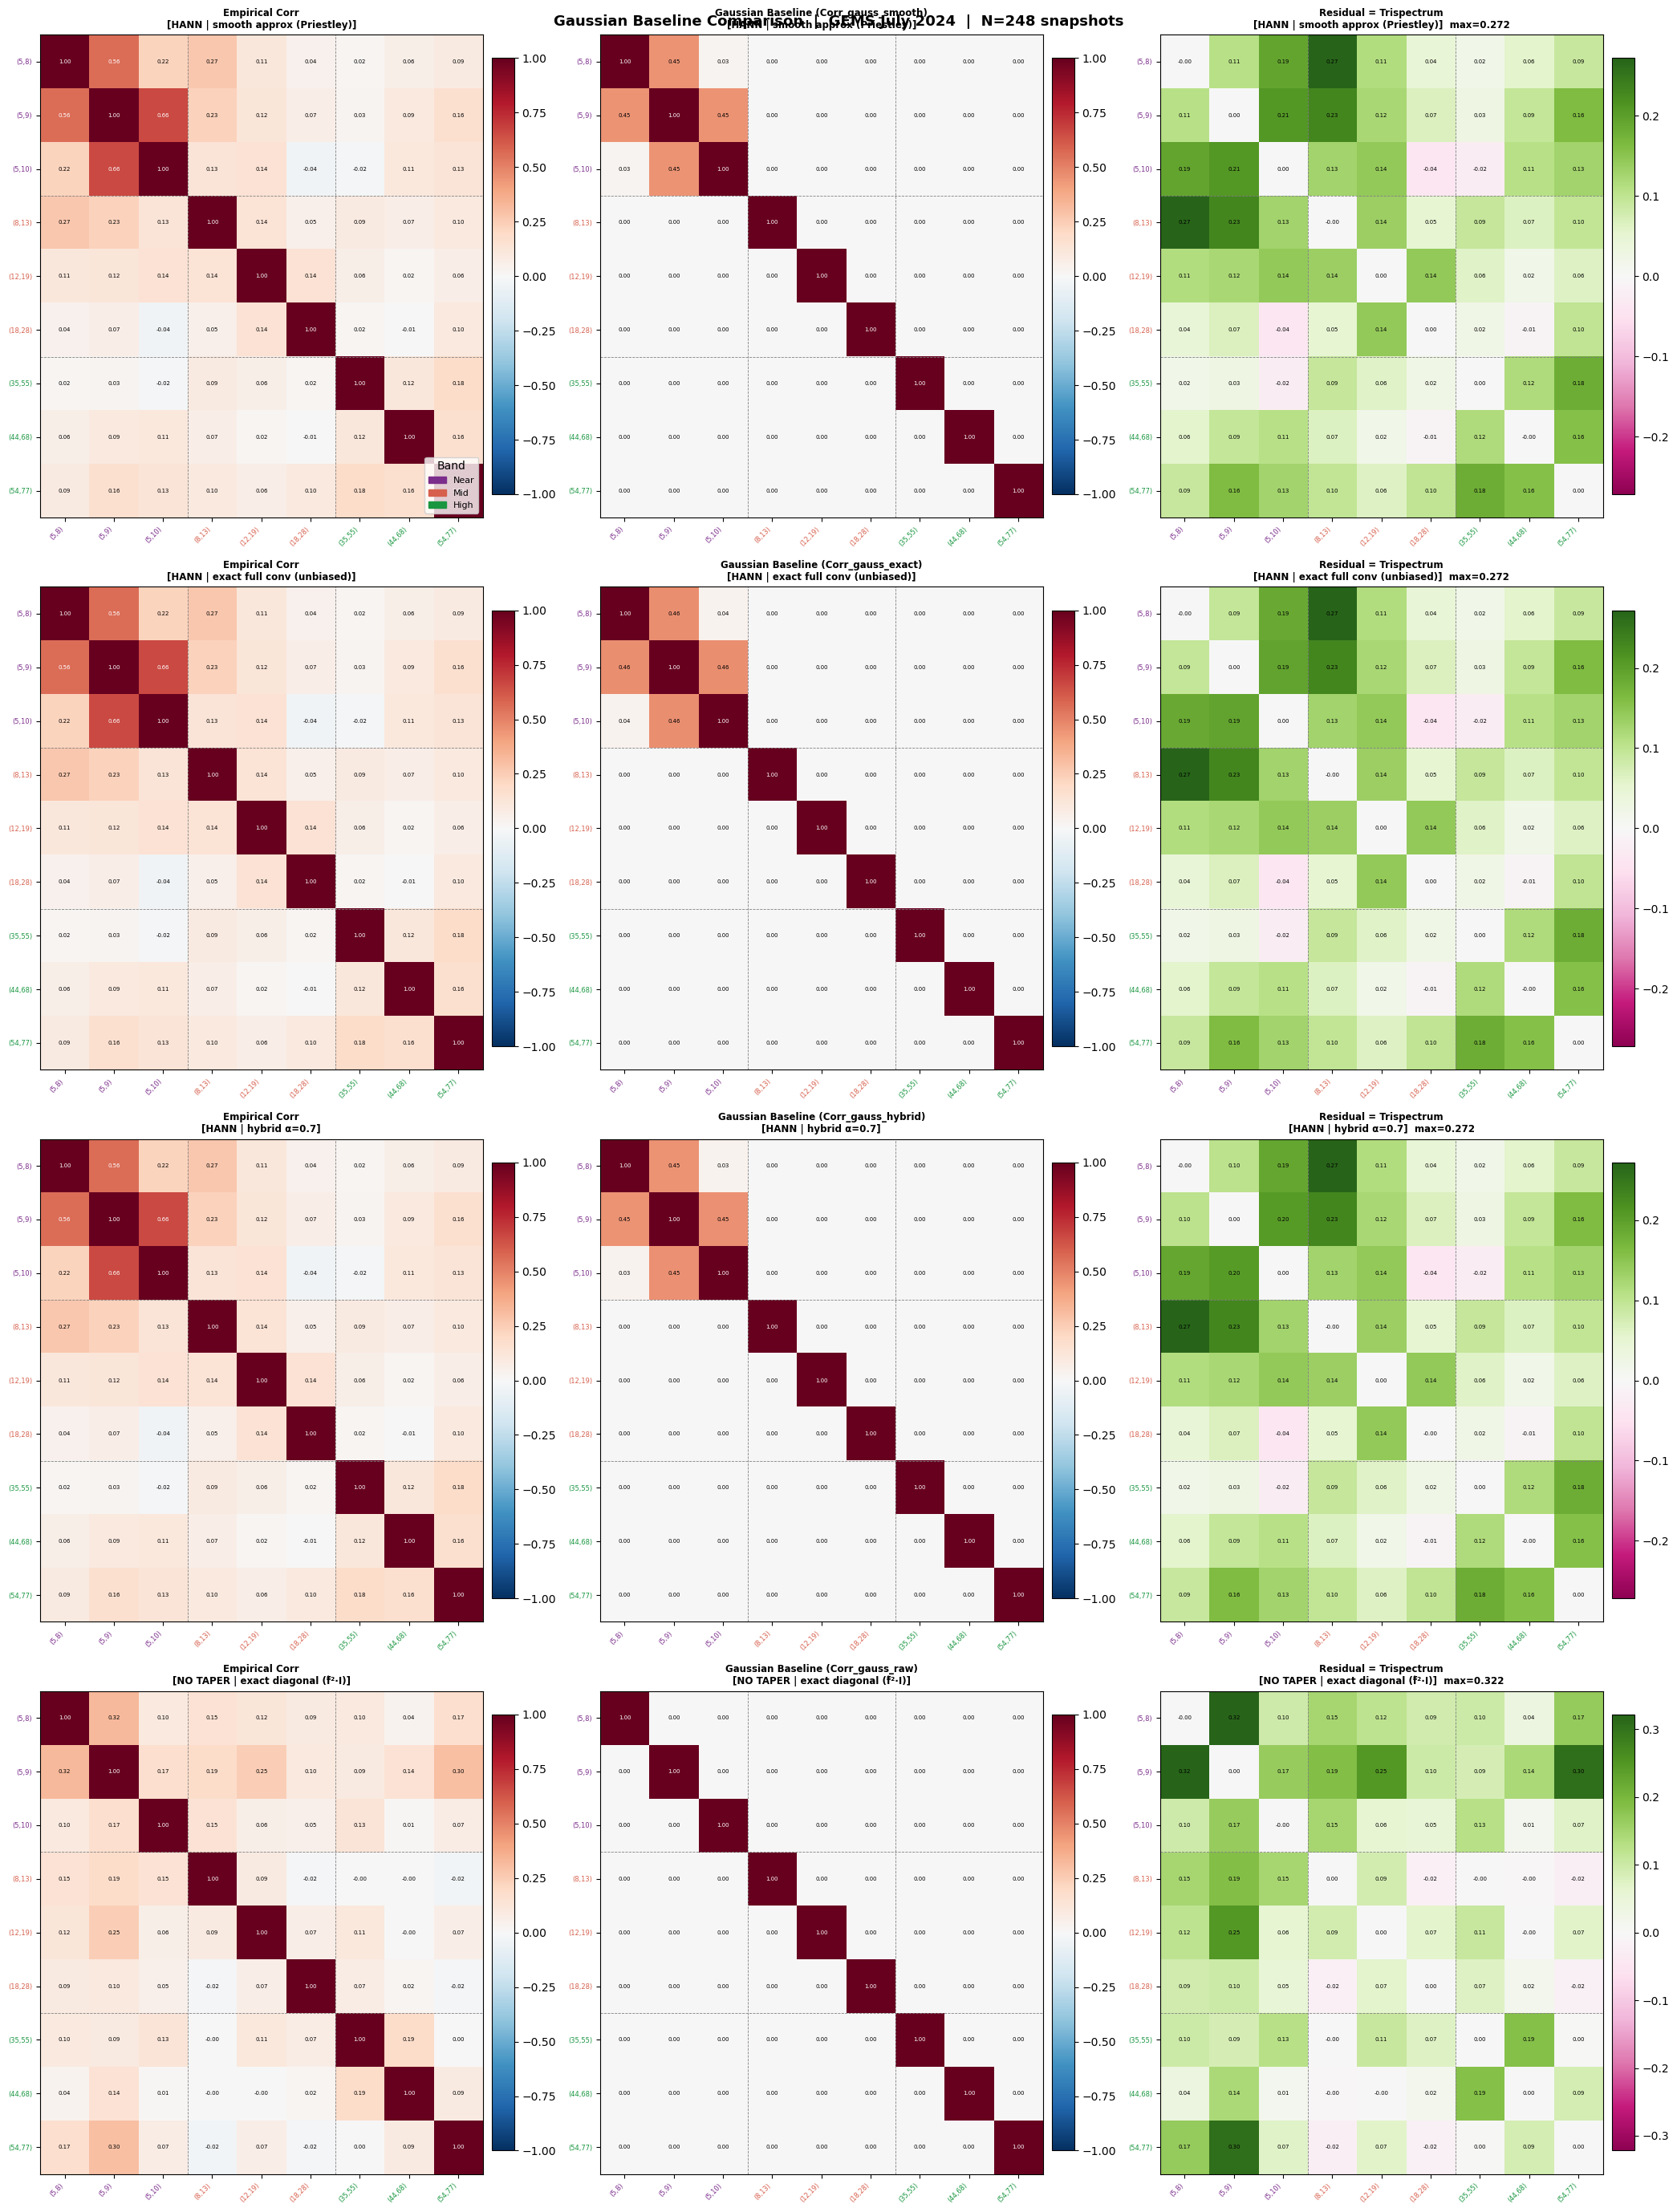

In [7]:
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Visualization: 4 × 3 grid
#   Each row:  Corr_emp  |  Corr_gauss  |  Residual (trispectrum estimate)
#   Row 1: HANN + smooth approx (Priestley, low-variance baseline)
#   Row 2: HANN + exact full conv (unbiased, high-variance baseline)
#   Row 3: HANN + hybrid (α=0.7)
#   Row 4: NO TAPER (exact diagonal baseline)
# ─────────────────────────────────────────────────────────────────────────────
band_colors_ = {"Near": "#7b2d8b", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels_ = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors_ = [band_colors_[b] for b in BAND_LABELS]
SEP_ = [2.5, 5.5]

def to_corr(cov):
    std = np.sqrt(np.clip(np.diag(cov), 1e-30, None))
    return cov / np.outer(std, std)

def draw_mat(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=8.5, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels_, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(tick_labels_, fontsize=6)
    for q, tc in enumerate(tick_colors_):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP_:
        ax.axhline(sep, color='gray', lw=0.6, ls='--')
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=5, color='white' if abs(mat[i,l]) > 0.5 else 'black')

# ── pre-compute correlation matrices ─────────────────────────────────────────
Cemp_tap    = to_corr(Cov_emp_tap)
Cgs_smooth  = to_corr(Cov_gauss_smooth)
Cgs_exact   = to_corr(Cov_gauss_exact)
Cgs_hybrid  = to_corr(Cov_gauss_hybrid)
Cemp_raw    = to_corr(Cov_emp_raw)
Cgs_raw     = np.eye(K)

rows = [
    (Cemp_tap, Cgs_smooth, "HANN | smooth approx (Priestley)",   "Corr_gauss_smooth"),
    (Cemp_tap, Cgs_exact,  "HANN | exact full conv (unbiased)",  "Corr_gauss_exact"),
    (Cemp_tap, Cgs_hybrid, f"HANN | hybrid α={ALPHA}",           "Corr_gauss_hybrid"),
    (Cemp_raw, Cgs_raw,    "NO TAPER | exact diagonal (f̂²·I)",  "Corr_gauss_raw"),
]

fig, axes = plt.subplots(4, 3, figsize=(21, 28))
fig.suptitle(
    f"Gaussian Baseline Comparison  |  GEMS July 2024  |  N={N_SNAP} snapshots",
    fontsize=13, fontweight='bold')

for row_idx, (Cemp, Cgauss, row_tag, gauss_name) in enumerate(rows):
    res = Cemp - Cgauss
    rlim = max(0.05, np.abs(res).max())
    draw_mat(axes[row_idx, 0], Cemp,   'RdBu_r', -1, 1,
             f"Empirical Corr\n[{row_tag}]")
    draw_mat(axes[row_idx, 1], Cgauss, 'RdBu_r', -1, 1,
             f"Gaussian Baseline ({gauss_name})\n[{row_tag}]")
    draw_mat(axes[row_idx, 2], res,    'PiYG', -rlim, rlim,
             f"Residual = Trispectrum\n[{row_tag}]  max={rlim:.3f}")

handles = [Patch(color=c, label=b) for b, c in band_colors_.items()]
axes[0, 0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')

plt.tight_layout()
plt.savefig('/tmp/cov_gauss_comparison_4row.png', dpi=120, bbox_inches='tight')
plt.show()

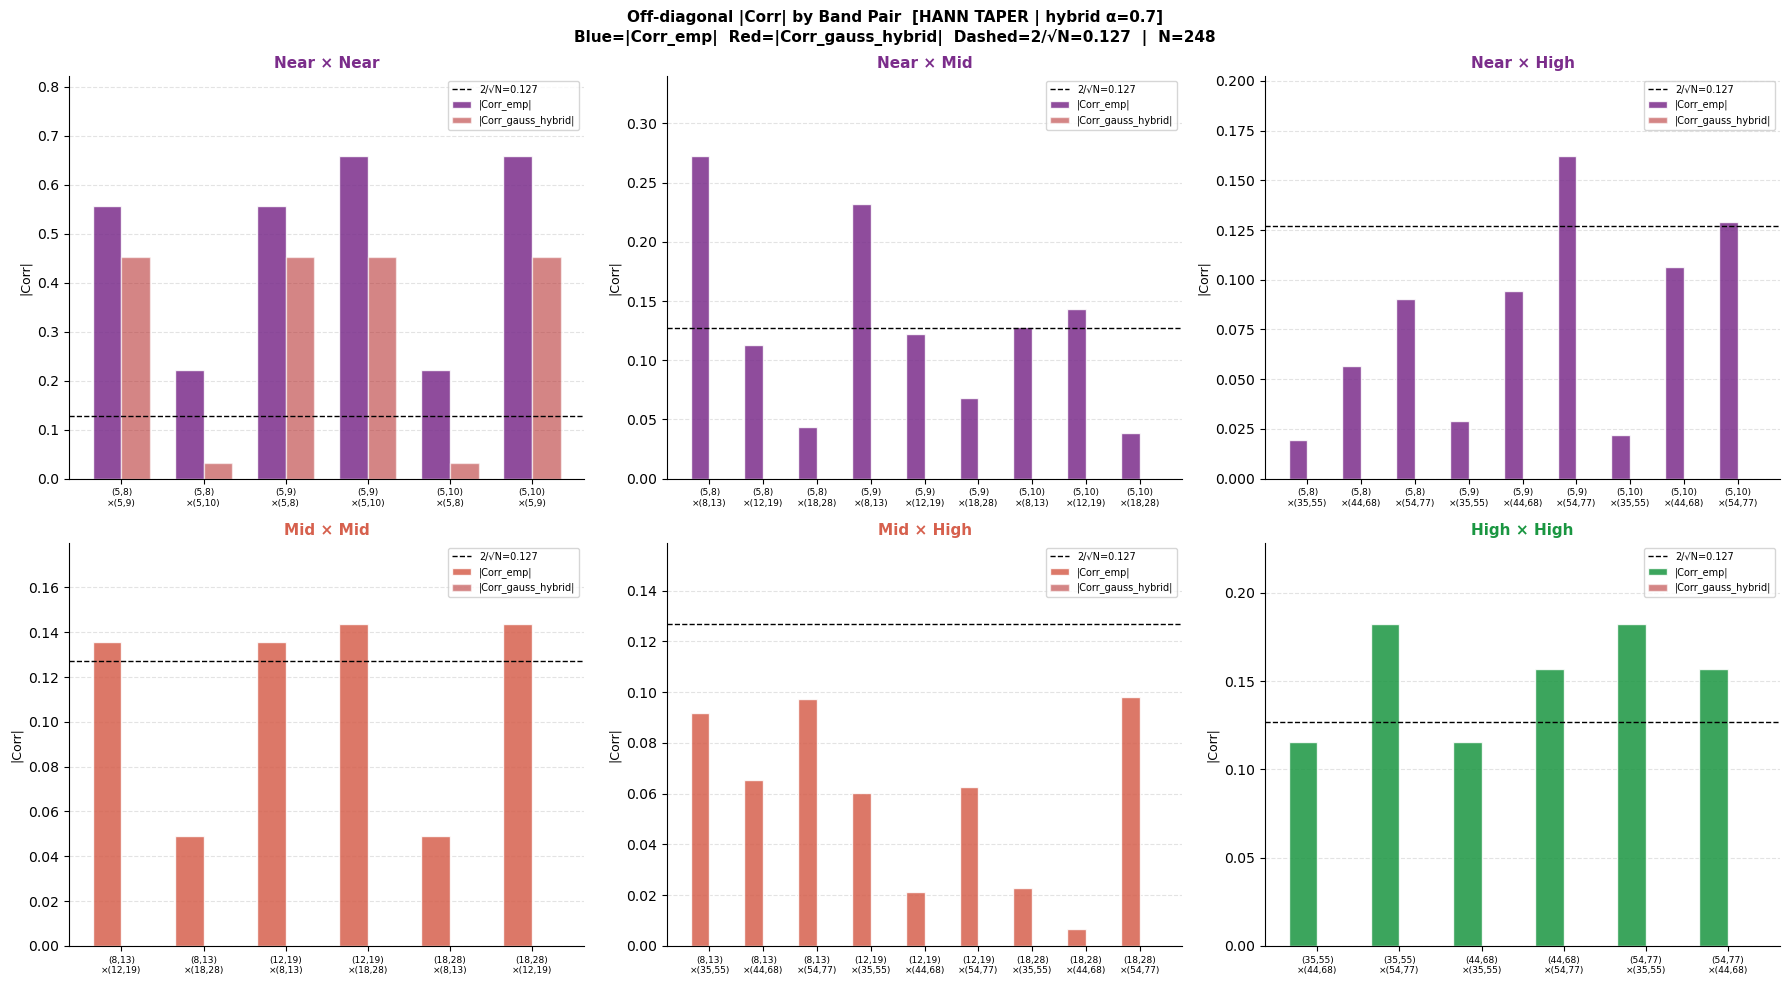


[HANN TAPER | hybrid α=0.7]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.6579        0.4536  6/6
  ⚠ Near ×Mid        0.2720        0.0000  4/9
  ⚠ Near ×High       0.1620        0.0000  2/9
  ⚠ Mid  ×Mid        0.1438        0.0000  4/6
    Mid  ×High       0.0983        0.0000  0/9
  ⚠ High ×High       0.1825        0.0000  4/6


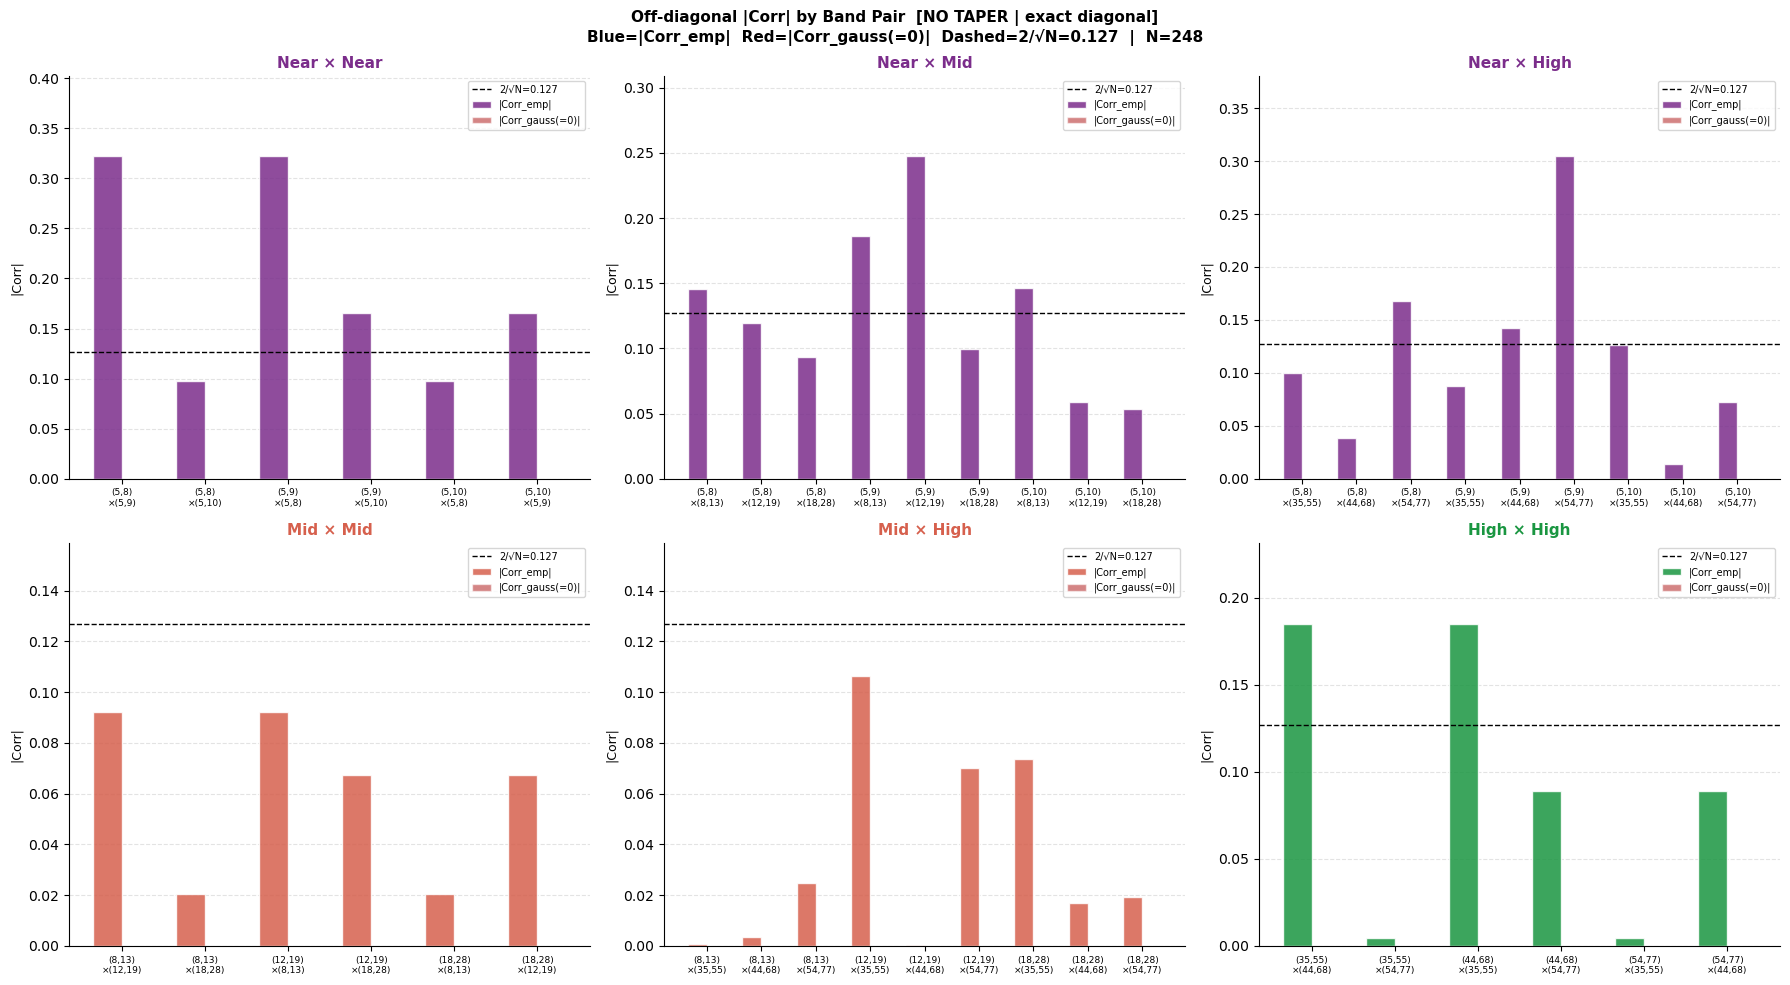


[NO TAPER | exact diagonal]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.3219        0.0000  4/6
  ⚠ Near ×Mid        0.2473        0.0000  4/9
  ⚠ Near ×High       0.3044        0.0000  3/9
    Mid  ×Mid        0.0922        0.0000  0/6
    Mid  ×High       0.1065        0.0000  0/9
  ⚠ High ×High       0.1851        0.0000  2/6


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic — Off-diagonal |Corr| by band pair
#   Uses variables defined in visualization cell above:
#     Cemp_tap / Cgs_hybrid  for taper version (hybrid baseline)
#     Cemp_raw / Cgs_raw     for no-taper version
# ─────────────────────────────────────────────────────────────────────────────
BANDS_IDX = {
    b: [i for i, bl in enumerate(BAND_LABELS) if bl == b]
    for b in ["Near", "Mid", "High"]
}
BAND_PAIRS = [("Near","Near"),("Near","Mid"),("Near","High"),
              ("Mid","Mid"),("Mid","High"),("High","High")]
sig_thresh = 2 / np.sqrt(N_SNAP)

def diag_offdiag(Corr_emp, Corr_gauss, title_tag, gauss_label):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        f"Off-diagonal |Corr| by Band Pair  [{title_tag}]\n"
        f"Blue=|Corr_emp|  Red=|{gauss_label}|  "
        f"Dashed=2/√N={sig_thresh:.3f}  |  N={N_SNAP}",
        fontsize=11, fontweight='bold')
    axes = axes.ravel()
    summary = []
    for ax_idx, (b1, b2) in enumerate(BAND_PAIRS):
        ax = axes[ax_idx]
        pe, pg, lbls = [], [], []
        for i in BANDS_IDX[b1]:
            for l in BANDS_IDX[b2]:
                if b1 == b2 and i == l:
                    continue
                pe.append(abs(Corr_emp[i, l]))
                pg.append(abs(Corr_gauss[i, l]))
                lbls.append(f"({FREQ_ALL[i][0]},{FREQ_ALL[i][1]})\n×({FREQ_ALL[l][0]},{FREQ_ALL[l][1]})")
        x = np.arange(len(pe)); w = 0.35
        ax.bar(x-w/2, pe, w, color=band_colors_.get(b1, "#555555"), alpha=0.85, edgecolor='w', label='|Corr_emp|')
        ax.bar(x+w/2, pg, w, color='firebrick',       alpha=0.55, edgecolor='w', label=f'|{gauss_label}|')
        ax.axhline(sig_thresh, color='k', ls='--', lw=1.0, label=f'2/√N={sig_thresh:.3f}')
        ax.set_title(f"{b1} × {b2}", fontsize=11, fontweight='bold', color=band_colors_.get(b1, "#555555"))
        ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=6.5)
        ax.set_ylabel("|Corr|", fontsize=9)
        ax.set_ylim(0, max(0.05, max(pe + pg + [sig_thresh]) * 1.25))
        ax.legend(fontsize=7)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, ls='--', alpha=0.35); ax.set_axisbelow(True)
        summary.append((b1, b2, max(pe), max(pg), sum(v > sig_thresh for v in pe), len(pe)))
    plt.tight_layout()
    plt.savefig(f'/tmp/offdiag_{title_tag.lower().replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\n[{title_tag}]  sig threshold = {sig_thresh:.4f}")
    print(f"{'Pair':>14}  {'max|emp|':>10}  {'max|gauss|':>12}  {'n_sig/n':>10}")
    print("-"*55)
    for b1_, b2_, me, mg, ns, np_ in summary:
        flag = "⚠" if me > sig_thresh else " "
        print(f"  {flag} {b1_:5s}×{b2_:5s}  {me:10.4f}  {mg:12.4f}  {ns}/{np_}")

# Taper: use hybrid baseline (α=0.7 shrinkage, best for physical detection)
diag_offdiag(Cemp_tap, Cgs_hybrid, f"HANN TAPER | hybrid α={ALPHA}", "Corr_gauss_hybrid")
# No-taper: use exact identity baseline
diag_offdiag(Cemp_raw, Cgs_raw,    "NO TAPER | exact diagonal",      "Corr_gauss(=0)")

## First-Difference Filter Analysis (2-1-1-0)

Debiased Whittle likelihood works on the **filtered field**:

$$Z(i,j) = -2\,X(i,j) + X(i+1,j) + X(i,j+1)$$

with spatial weights $\{(0,0){:}{-2},\,(1,0){:}{+1},\,(0,1){:}{+1}\}$ — same kernel as in `debiased_whittle_2110.py`.

**Why filter first?**  
- Raw field: spectral density drops $\sim 4$ orders of magnitude from Low to High band ($\hat{f} \approx 4000 \to 2$)  
- After 2-1-1-0: spectral shape flatter → smooth approx bias reduced, Gaussian baseline more accurate  
- Grid shrinks: $(M,N)=(114,159) \to (113,158)$

**Questions checked below:**  
1. Does empirical off-diagonal correlation change after filtering?  
2. Does the gap between `Cov_emp` and `Cov_gauss_exact` close?

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# ─────────────────────────────────────────────────────────────────────────────
# Filter setup
#   Z(i,j) = -2·X(i,j) + X(i+1,j) + X(i,j+1)
#   Grid: (M_grid, N_grid) = (114, 159) → (113, 158)
# ─────────────────────────────────────────────────────────────────────────────
M_d = M_grid - 1   # 113
N_d = N_grid - 1   # 158

H_d  = np.outer(np.hanning(M_d), np.hanning(N_d))
H_d /= np.sqrt(np.mean(H_d**2))
F_H2_d  = fftn(H_d**2)
H_dft_d = fftn(H_d)

MN_d  = M_d * N_d
MN2_d = float(MN_d)**2
scale_d = np.sqrt(MN_d)

# Frequency indices remapped to filtered grid (same physical frequency → same index)
# Frequencies chosen earlier still valid; just check they're within (M_d//2, N_d//2)
for (j1, j2) in FREQ_ALL:
    assert j1 < M_d // 2 and j2 < N_d // 2, f"freq {(j1,j2)} out of range for ({M_d},{N_d})"

print(f"Filtered grid: {M_d}×{N_d}  |  taper ||H||² / (MN) = {np.mean(H_d**2):.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Collect snapshots on FILTERED field
# ─────────────────────────────────────────────────────────────────────────────
N_SNAP = N_DAYS * 8
J_tap_d = np.zeros((N_SNAP, K), dtype=complex)
J_raw_d = np.zeros((N_SNAP, K), dtype=complex)
f_full_d = np.zeros((M_d, N_d), dtype=float)

print(f"Extracting DFT coefficients (filtered): {N_SNAP} snapshots × {K} frequencies ...")
idx = 0
for d in range(N_DAYS):
    keys = sorted(daily_hourly_maps[d].keys())
    for key in keys[:8]:
        t    = daily_hourly_maps[d][key]
        grid = np.nan_to_num(t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0)
        g    = grid - grid.mean()

        # 2-1-1-0 first-difference filter
        g_d = -2.0 * g[:-1, :-1] + g[1:, :-1] + g[:-1, 1:]

        F_tap_d = fftn(g_d * H_d)
        F_raw_d = fftn(g_d)
        f_full_d += np.abs(F_tap_d)**2 / MN_d

        for q, (j1, j2) in enumerate(FREQ_ALL):
            J_tap_d[idx, q] = F_tap_d[j1, j2] / scale_d
            J_raw_d[idx, q] = F_raw_d[j1, j2] / scale_d
        idx += 1

f_full_d /= N_SNAP

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Periodogram + empirical covariance
# ─────────────────────────────────────────────────────────────────────────────
I_tap_d = np.abs(J_tap_d)**2
I_raw_d = np.abs(J_raw_d)**2
f_hat_tap_d = I_tap_d.mean(axis=0)
f_hat_raw_d = I_raw_d.mean(axis=0)

def emp_cov(I):
    Ic = I - I.mean(axis=0)
    return (Ic.T @ Ic) / I.shape[0]

Cov_emp_tap_d = emp_cov(I_tap_d)
Cov_emp_raw_d = emp_cov(I_raw_d)

# ─────────────────────────────────────────────────────────────────────────────
# Step 3a: Smooth approx (Priestley) on filtered grid
# ─────────────────────────────────────────────────────────────────────────────
Cov_gauss_smooth_d = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    for l, (k1, k2) in enumerate(FREQ_ALL):
        dm = ((j1-k1) % M_d, (j2-k2) % N_d)
        dp = ((j1+k1) % M_d, (j2+k2) % N_d)
        Cov_gauss_smooth_d[i, l] = (
            f_hat_tap_d[i] * f_hat_tap_d[l]
            * (abs(F_H2_d[dm])**2 + abs(F_H2_d[dp])**2)
            / MN2_d
        )

# ─────────────────────────────────────────────────────────────────────────────
# Step 3b: Exact full convolution on filtered grid
# ─────────────────────────────────────────────────────────────────────────────
m1_d = np.arange(M_d)[:, None]
m2_d = np.arange(N_d)[None, :]

print("Computing exact Gaussian covariance (filtered field) ...")
Cov_gauss_exact_d = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    H_j_d = H_dft_d[(j1 - m1_d) % M_d, (j2 - m2_d) % N_d]
    for l, (k1, k2) in enumerate(FREQ_ALL):
        H_k_conj_d = np.conj(H_dft_d[(k1 - m1_d) % M_d, (k2 - m2_d) % N_d])
        H_k_pos_d  = H_dft_d[(k1 + m1_d) % M_d, (k2 + m2_d) % N_d]
        S_jk = np.sum(f_full_d * H_j_d * H_k_conj_d) / MN2_d
        P_jk = np.sum(f_full_d * H_j_d * H_k_pos_d)  / MN2_d
        Cov_gauss_exact_d[i, l] = abs(S_jk)**2 + abs(P_jk)**2

Cov_gauss_hybrid_d = ALPHA * Cov_gauss_smooth_d + (1 - ALPHA) * Cov_gauss_exact_d
Cov_gauss_raw_d    = np.diag(f_hat_raw_d**2)

# Trispectrum residuals
Cov_ng_smooth_d = Cov_emp_tap_d - Cov_gauss_smooth_d
Cov_ng_exact_d  = Cov_emp_tap_d - Cov_gauss_exact_d
Cov_ng_hybrid_d = Cov_emp_tap_d - Cov_gauss_hybrid_d
Cov_ng_raw_d    = Cov_emp_raw_d - Cov_gauss_raw_d

# ─────────────────────────────────────────────────────────────────────────────
# Summary: raw vs filtered spectral density + variance ratios
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_raw':>10}  {'f̂_filt':>10}  "
      f"{'ratio':>7}  {'Var_emp_raw':>13}  {'Var_emp_filt':>14}")
print("-"*90)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    r = f_hat_tap_d[q] / f_hat_tap[q] if f_hat_tap[q] > 0 else float('nan')
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat_tap[q]:10.4f}  {f_hat_tap_d[q]:10.4f}  {r:7.4f}  "
          f"{Cov_emp_tap[q,q]:13.4f}  {Cov_emp_tap_d[q,q]:14.4f}")

Filtered grid: 113×158  |  taper ||H||² / (MN) = 1.0000
Extracting DFT coefficients (filtered): 248 snapshots × 9 frequencies ...
Computing exact Gaussian covariance (filtered field) ...

  q   Band          freq      f̂_raw     f̂_filt    ratio    Var_emp_raw    Var_emp_filt
------------------------------------------------------------------------------------------
   0  Near   (  5,  8)     44.7036     15.5750   0.3484      3369.4135        399.4883
   1  Near   (  5,  9)     47.5754     18.0971   0.3804      4672.4794        652.1855
   2  Near   (  5, 10)     39.1586     16.7294   0.4272      2644.5038        456.8417
   3  Mid    (  8, 13)     22.3991     19.4154   0.8668       774.1995        552.3530
   4  Mid    ( 12, 19)     10.7746     20.9062   1.9403       216.9352        877.2656
   5  Mid    ( 18, 28)      4.7712     18.8621   3.9533        27.2994        423.0494
   6  High   ( 35, 55)      1.9815     24.5106  12.3697         3.6797        552.6878
   7  High   ( 44, 68) 

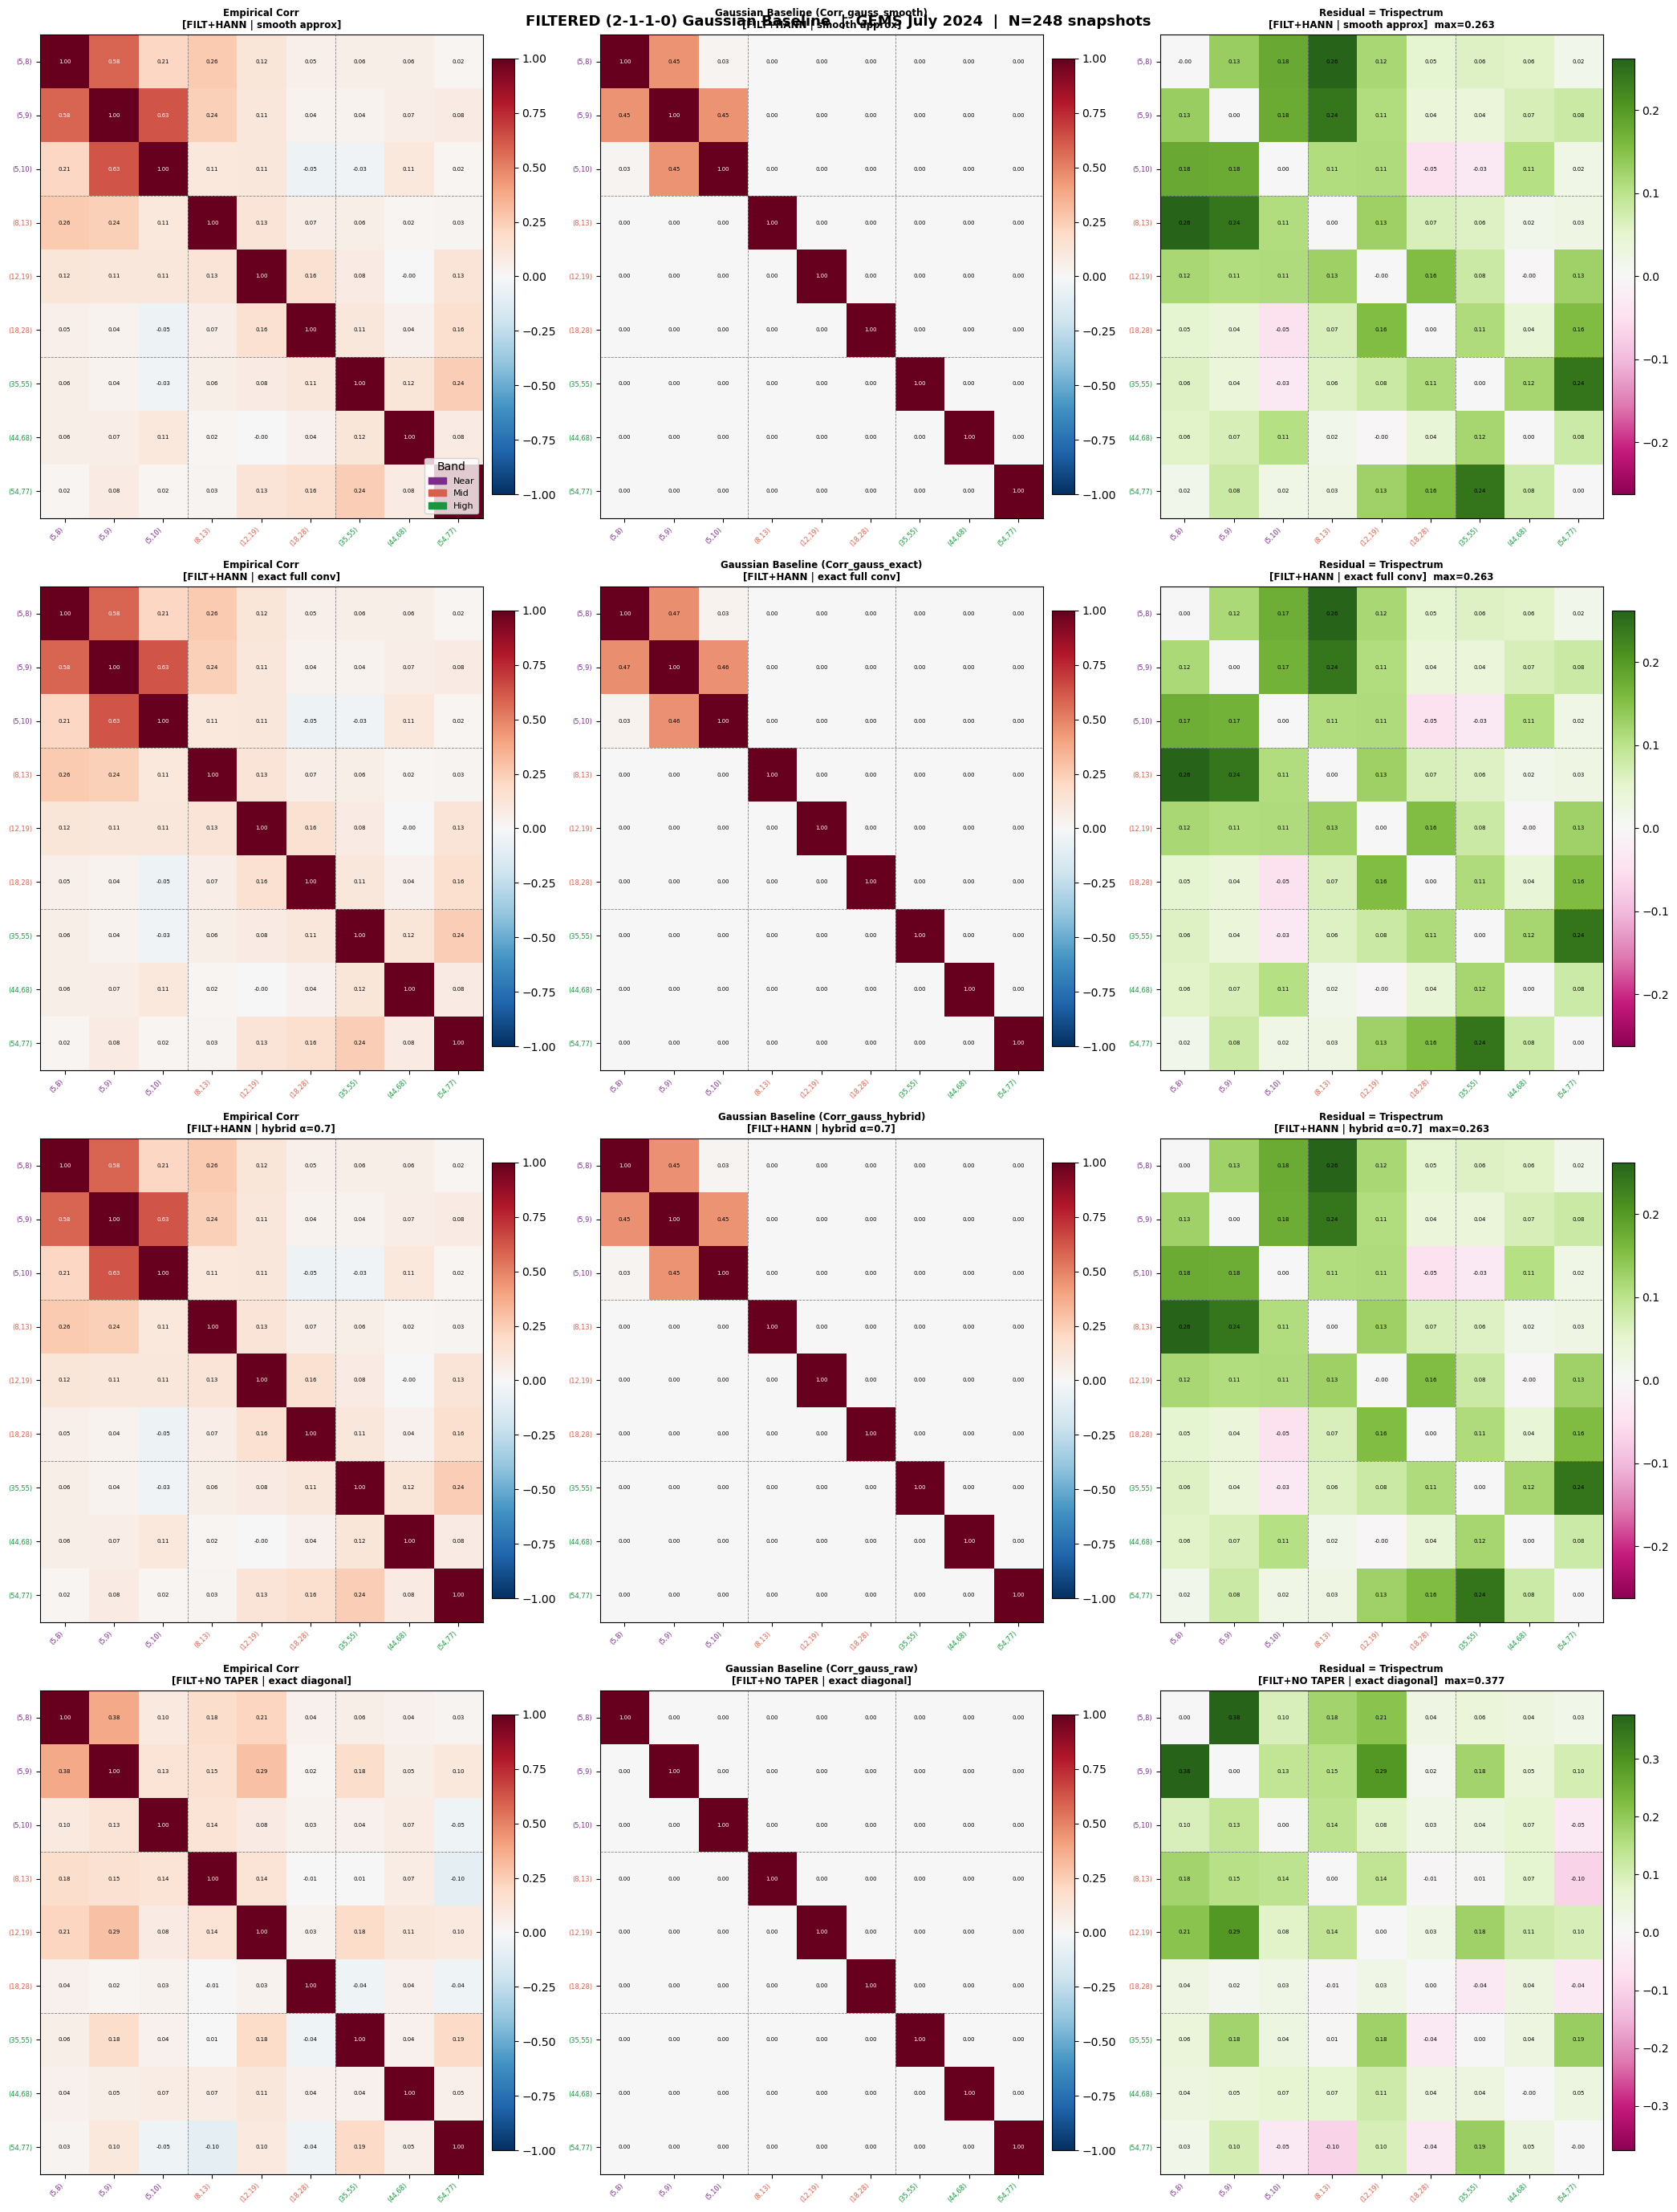

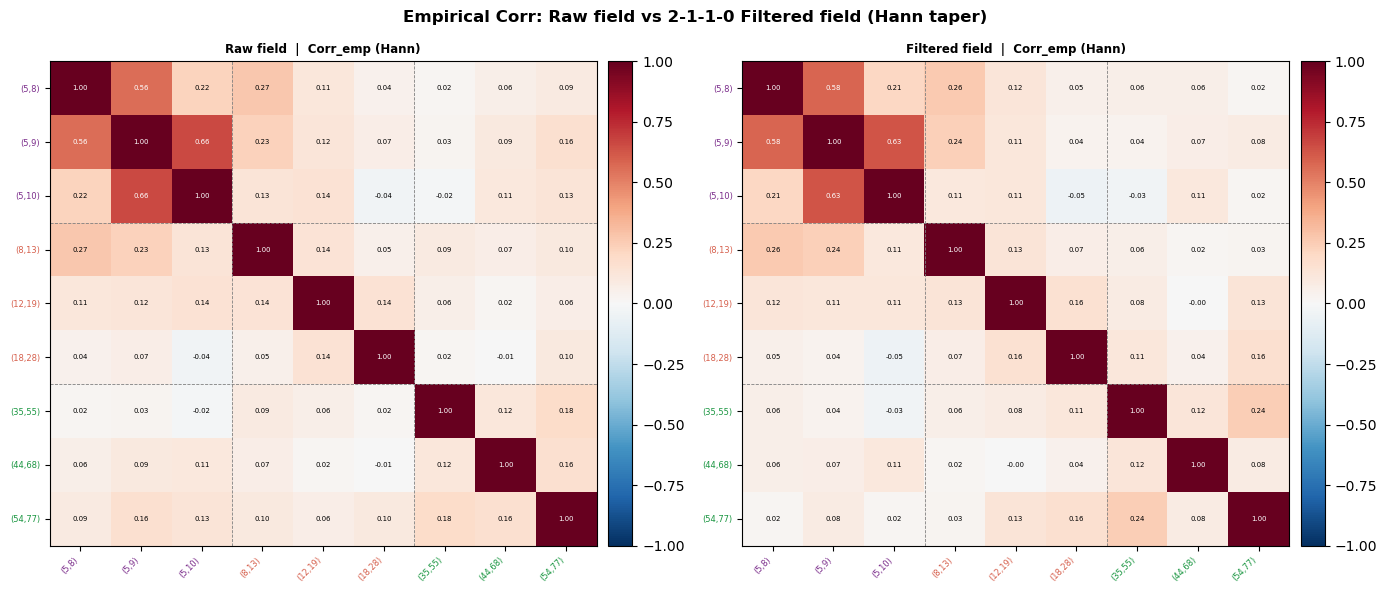

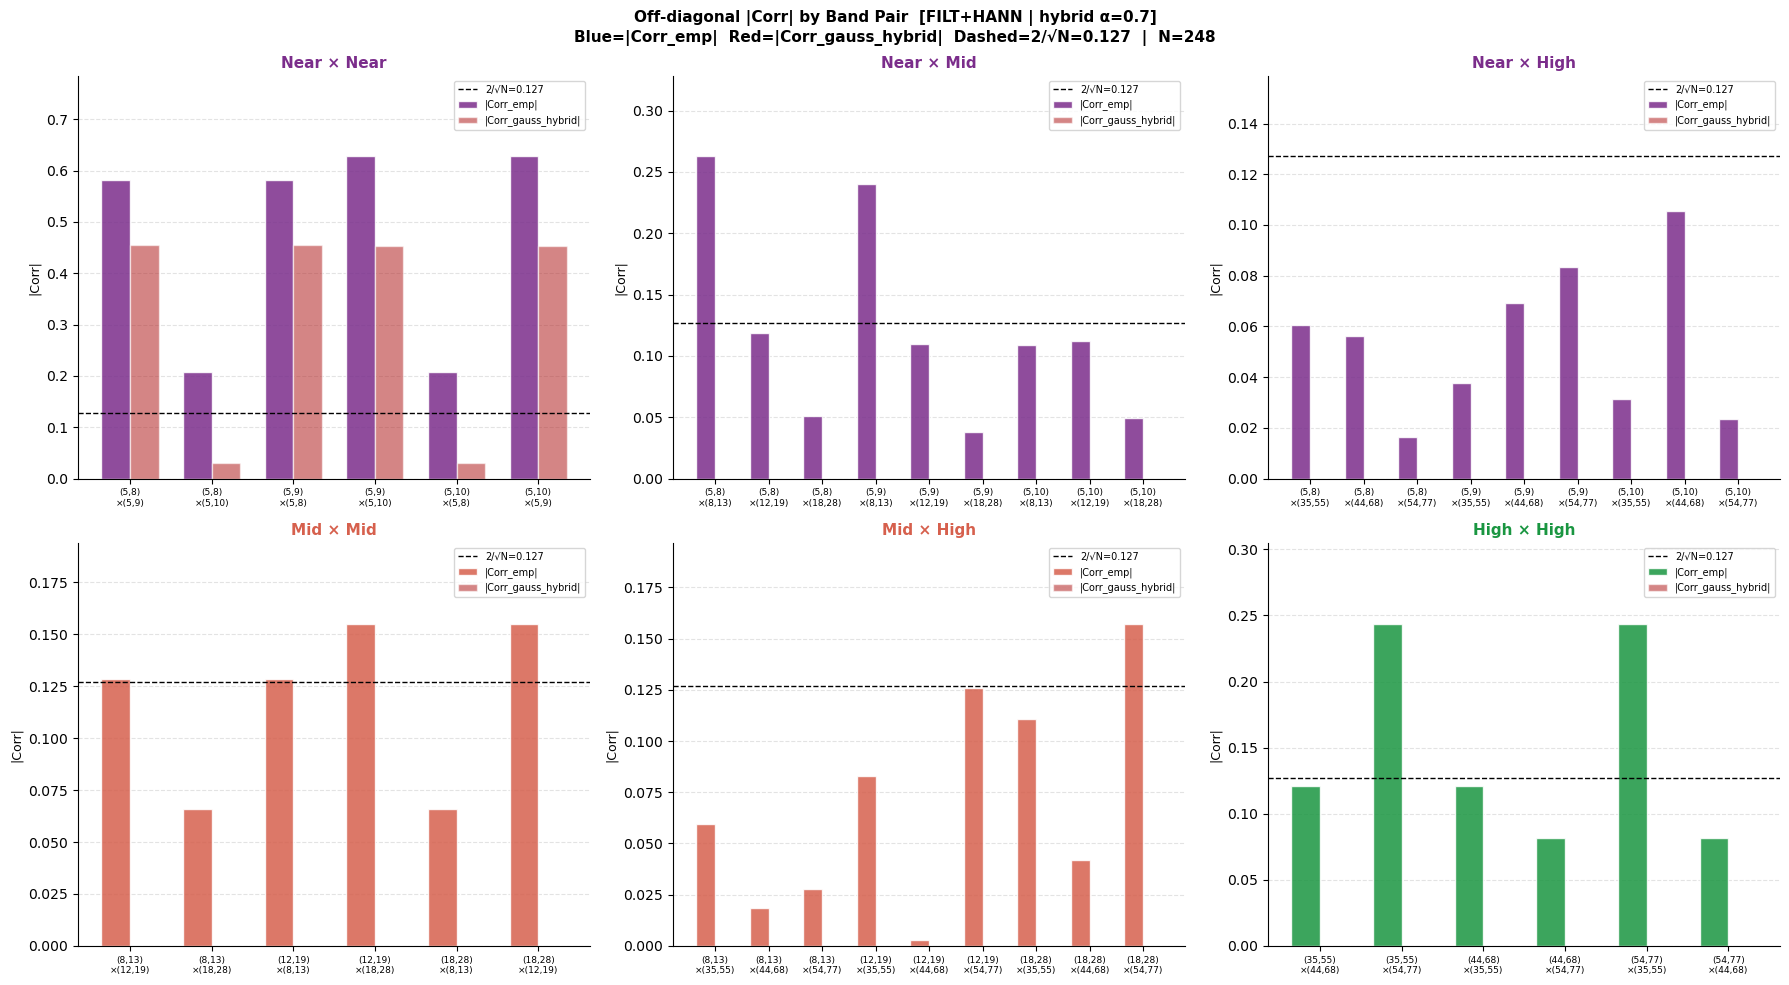


[FILT+HANN | hybrid α=0.7]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.6275        0.4542  6/6
  ⚠ Near ×Mid        0.2625        0.0000  2/9
    Near ×High       0.1056        0.0000  0/9
  ⚠ Mid  ×Mid        0.1551        0.0000  4/6
  ⚠ Mid  ×High       0.1573        0.0000  1/9
  ⚠ High ×High       0.2438        0.0000  2/6


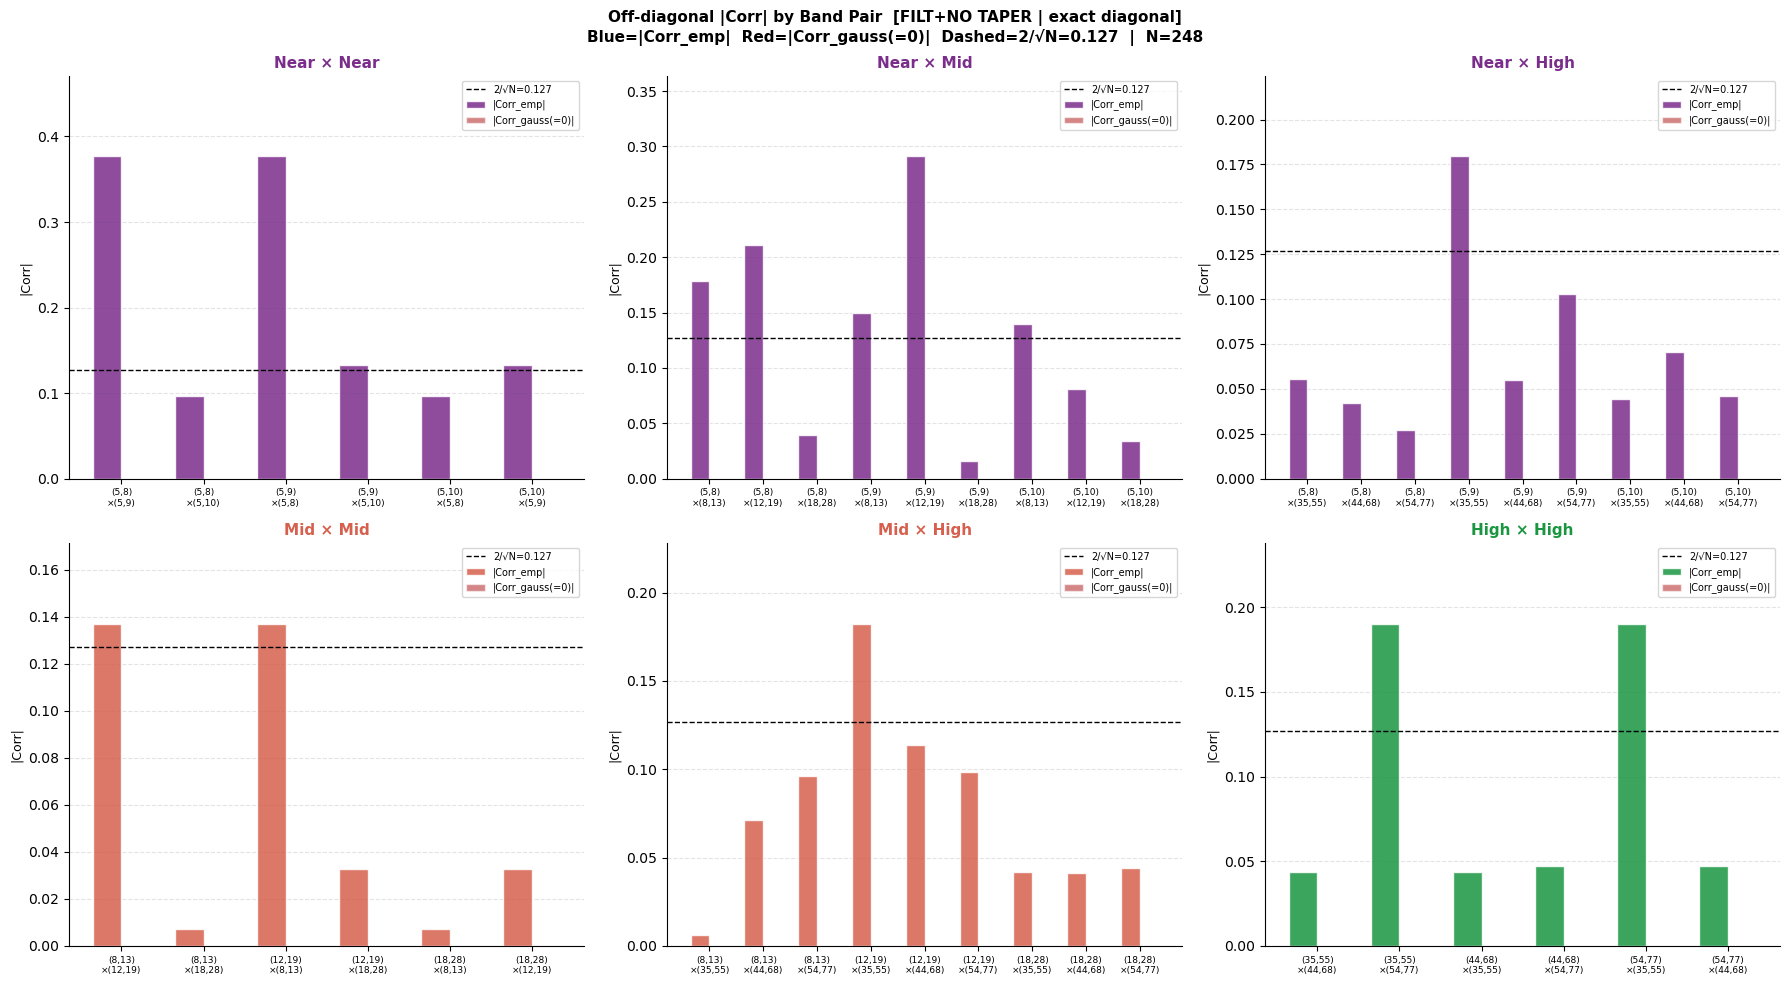


[FILT+NO TAPER | exact diagonal]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.3766        0.0000  4/6
  ⚠ Near ×Mid        0.2909        0.0000  5/9
  ⚠ Near ×High       0.1794        0.0000  1/9
  ⚠ Mid  ×Mid        0.1371        0.0000  2/6
  ⚠ Mid  ×High       0.1824        0.0000  1/9
  ⚠ High ×High       0.1903        0.0000  2/6


In [10]:
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Visualization: filtered field — same 4-row layout as before
# ─────────────────────────────────────────────────────────────────────────────
band_colors_ = {"Near": "#7b2d8b", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels_ = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors_ = [band_colors_[b] for b in BAND_LABELS]
SEP_ = [2.5, 5.5]

def to_corr(cov):
    std = np.sqrt(np.clip(np.diag(cov), 1e-30, None))
    return cov / np.outer(std, std)

def draw_mat(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=8.5, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels_, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(tick_labels_, fontsize=6)
    for q, tc in enumerate(tick_colors_):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP_:
        ax.axhline(sep, color='gray', lw=0.6, ls='--')
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=5, color='white' if abs(mat[i,l]) > 0.5 else 'black')

Cemp_tap_d   = to_corr(Cov_emp_tap_d)
Cgs_smooth_d = to_corr(Cov_gauss_smooth_d)
Cgs_exact_d  = to_corr(Cov_gauss_exact_d)
Cgs_hybrid_d = to_corr(Cov_gauss_hybrid_d)
Cemp_raw_d   = to_corr(Cov_emp_raw_d)
Cgs_raw_d    = np.eye(K)

rows_d = [
    (Cemp_tap_d, Cgs_smooth_d, "FILT+HANN | smooth approx",        "Corr_gauss_smooth"),
    (Cemp_tap_d, Cgs_exact_d,  "FILT+HANN | exact full conv",       "Corr_gauss_exact"),
    (Cemp_tap_d, Cgs_hybrid_d, f"FILT+HANN | hybrid α={ALPHA}",     "Corr_gauss_hybrid"),
    (Cemp_raw_d, Cgs_raw_d,    "FILT+NO TAPER | exact diagonal",    "Corr_gauss_raw"),
]

fig, axes = plt.subplots(4, 3, figsize=(21, 28))
fig.suptitle(
    f"FILTERED (2-1-1-0) Gaussian Baseline  |  GEMS July 2024  |  N={N_SNAP} snapshots",
    fontsize=13, fontweight='bold')

for row_idx, (Cemp, Cgauss, row_tag, gauss_name) in enumerate(rows_d):
    res = Cemp - Cgauss
    rlim = max(0.05, np.abs(res).max())
    draw_mat(axes[row_idx, 0], Cemp,   'RdBu_r', -1, 1,
             f"Empirical Corr\n[{row_tag}]")
    draw_mat(axes[row_idx, 1], Cgauss, 'RdBu_r', -1, 1,
             f"Gaussian Baseline ({gauss_name})\n[{row_tag}]")
    draw_mat(axes[row_idx, 2], res,    'PiYG', -rlim, rlim,
             f"Residual = Trispectrum\n[{row_tag}]  max={rlim:.3f}")

handles = [Patch(color=c, label=b) for b, c in band_colors_.items()]
axes[0, 0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')
plt.tight_layout()
plt.savefig('/tmp/cov_gauss_filtered_4row.png', dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Side-by-side: RAW vs FILTERED empirical correlation
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle("Empirical Corr: Raw field vs 2-1-1-0 Filtered field (Hann taper)",
              fontsize=12, fontweight='bold')
draw_mat(axes2[0], to_corr(Cov_emp_tap),   'RdBu_r', -1, 1, "Raw field  |  Corr_emp (Hann)")
draw_mat(axes2[1], Cemp_tap_d,             'RdBu_r', -1, 1, "Filtered field  |  Corr_emp (Hann)")
plt.tight_layout()
plt.savefig('/tmp/cov_emp_raw_vs_filtered.png', dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Off-diagonal diagnostic: filtered hybrid baseline
# ─────────────────────────────────────────────────────────────────────────────
BANDS_IDX = {b: [i for i, bl in enumerate(BAND_LABELS) if bl == b]
             for b in ["Near", "Mid", "High"]}
BAND_PAIRS = [("Near","Near"),("Near","Mid"),("Near","High"),
              ("Mid","Mid"),("Mid","High"),("High","High")]
sig_thresh = 2 / np.sqrt(N_SNAP)

def diag_offdiag(Corr_emp, Corr_gauss, title_tag, gauss_label):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        f"Off-diagonal |Corr| by Band Pair  [{title_tag}]\n"
        f"Blue=|Corr_emp|  Red=|{gauss_label}|  "
        f"Dashed=2/√N={sig_thresh:.3f}  |  N={N_SNAP}",
        fontsize=11, fontweight='bold')
    axes = axes.ravel()
    summary = []
    for ax_idx, (b1, b2) in enumerate(BAND_PAIRS):
        ax = axes[ax_idx]
        pe, pg, lbls = [], [], []
        for i in BANDS_IDX[b1]:
            for l in BANDS_IDX[b2]:
                if b1 == b2 and i == l:
                    continue
                pe.append(abs(Corr_emp[i, l]))
                pg.append(abs(Corr_gauss[i, l]))
                lbls.append(f"({FREQ_ALL[i][0]},{FREQ_ALL[i][1]})\n×({FREQ_ALL[l][0]},{FREQ_ALL[l][1]})")
        x = np.arange(len(pe)); w = 0.35
        ax.bar(x-w/2, pe, w, color=band_colors_.get(b1, "#555555"), alpha=0.85, edgecolor='w', label='|Corr_emp|')
        ax.bar(x+w/2, pg, w, color='firebrick',       alpha=0.55, edgecolor='w', label=f'|{gauss_label}|')
        ax.axhline(sig_thresh, color='k', ls='--', lw=1.0, label=f'2/√N={sig_thresh:.3f}')
        ax.set_title(f"{b1} × {b2}", fontsize=11, fontweight='bold', color=band_colors_.get(b1, "#555555"))
        ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=6.5)
        ax.set_ylabel("|Corr|", fontsize=9)
        ax.set_ylim(0, max(0.05, max(pe + pg + [sig_thresh]) * 1.25))
        ax.legend(fontsize=7)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, ls='--', alpha=0.35); ax.set_axisbelow(True)
        summary.append((b1, b2, max(pe), max(pg), sum(v > sig_thresh for v in pe), len(pe)))
    plt.tight_layout()
    plt.savefig(f'/tmp/offdiag_{title_tag.lower().replace(" ","_").replace("|","").replace("=","")}.png',
                dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\n[{title_tag}]  sig threshold = {sig_thresh:.4f}")
    print(f"{'Pair':>14}  {'max|emp|':>10}  {'max|gauss|':>12}  {'n_sig/n':>10}")
    print("-"*55)
    for b1_, b2_, me, mg, ns, np_ in summary:
        flag = "⚠" if me > sig_thresh else " "
        print(f"  {flag} {b1_:5s}×{b2_:5s}  {me:10.4f}  {mg:12.4f}  {ns}/{np_}")

diag_offdiag(Cemp_tap_d, Cgs_hybrid_d,
             f"FILT+HANN | hybrid α={ALPHA}", "Corr_gauss_hybrid")
diag_offdiag(Cemp_raw_d, Cgs_raw_d,
             "FILT+NO TAPER | exact diagonal", "Corr_gauss(=0)")